# Tokenizer

This file tokenizes the html row signals into discrete, concrete types. To narrow the scope, we focus on Two Friends Big Bootie Mixes. 

These mixes are chosen because they provide sufficiently complex audio data (acappella and instrumental overlays, loops, etc.), easily downloadable DJ Set Media Links, and mostly labeled data.

Once we have created a sufficiently rigorous pipeline for labeling the data, then we can expand to the entire dataset and more nuanced sets, such as those with suggestions. 

In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from common import (
    get_dj_metadata_df,
    get_dj_sets_with_at_least_one_dj_set_media_link,
    get_dj_set_rows_with_at_least_one_dj_set_media_link,
)

REPO_ROOT = Path("/Users/johnnycabrahams/Desktop/tracklist_engine")
DB_PATH   = REPO_ROOT / "data" / "db" / "music_database.db"
JSON_DIR  = REPO_ROOT / "data" / "djs"
HTML_DIR  = REPO_ROOT / "data" / "html"

conn = sqlite3.connect(str(DB_PATH))
cur  = conn.cursor()
print(f'connected: {DB_PATH}')

connected: /Users/johnnycabrahams/Desktop/tracklist_engine/data/db/music_database.db


## The row-type taxonomy

Every row in `dj_set_rows` is one of three families, distinguishable by the
CSS class on its outer `<div>`:

| Outer class       | Row kind     | What it represents                                           | Parser                        |
|-------------------|--------------|--------------------------------------------------------------|-------------------------------|
| `tlpItem`         | `track`      | A track played in the set (the main case).                   | `parse_track_row`            |
| `sugTog`          | `suggestion` | A user-submitted ID for an otherwise-unknown track.          | `parse_suggestion_row`       |
| `bItmH`           | `text`       | A header / notice / "identical tracklist" link / recycle CTA.| `parse_bItmH_row`            |
| (none of the above) | page chrome | The hidden HTML5 player widget or the "save tracklist" bar. | dispatched to `None`          |

The dispatcher is `tokenizers.tokenize_row(raw_html)` and the thin version that
only reports the family is `tokenizers.classify_row(raw_html)`. The track-row
parser is by far the richest — it extracts identity, ordering, timing, artist
& label metadata, community flags, and the platform icons attached to each
row. We exercise it below against the Big Bootie corpus.

In [2]:
# Show the tokenizer working on a single real row before we go corpus-wide.
import sys
sys.path.insert(0, str(Path.cwd().parent))   # repo root, so `row_tokens/` resolves
from row_tokens import tokenize_row, classify_row

sample_html = conn.execute(
    """
    SELECT raw_html FROM dj_set_rows
    WHERE set_id = '1d9zwh49' AND row_index = 1
    """
).fetchone()[0]

kind = classify_row(sample_html)
token = tokenize_row(sample_html)
print(f'row kind: {kind}')
print(f'token fields (non-empty):')
for f, v in token.__dict__.items():
    if v not in (None, '', False, [], ()):
        print(f'  {f:28s} = {v!r}')

row kind: track
token fields (non-empty):
  row_dom_id                   = 'tlp_12246398'
  data_id                      = 12246398
  is_ided                      = True
  track_number_raw             = '01'
  track_key                    = 'gp7b7p'
  track_page_href              = '/track/gp7b7p/nirvana-smells-like-teen-spirit/index.html'
  google_query_href            = 'https://www.google.com/search?q=Nirvana+Smells+Like+Teen+Spirit'
  title                        = 'Smells Like Teen Spirit'
  artists                      = ['Nirvana']
  full_name                    = 'Nirvana - Smells Like Teen Spirit'
  genre                        = 'Progressive House'
  duration_iso                 = 'PT5M1S'
  duration_seconds             = 301
  plays                        = 1247
  iders                        = [UserRef(username='litchay', profile_href='/user/litchay/index.html', reputation_text='(111.4k)')]
  media_track_numeric_id       = 2022
  media_flags                  = MediaFlags(yo

### Retrieving the Data

To retrieve the relevant Two Friends data, we need to extract the Sets, the corresponding set rows, the set media links, and the track media links. 

In [3]:
# Big Bootie data access lives in `big_bootie.py` now — no ad-hoc SQL in this notebook.
from big_bootie import (
    load_big_bootie_sets, load_big_bootie_rows, load_big_bootie_track_media_links,
    tokenize_rows,
)

bb_sets = load_big_bootie_sets(conn)
bb_rows = load_big_bootie_rows(conn)
bb_tml  = load_big_bootie_track_media_links(conn)

print(f'sets: {len(bb_sets)}   rows: {len(bb_rows)}   track_media_links: {len(bb_tml)}')
bb_sets[['set_id', 'volume', 'date_played', 'title']].head()

sets: 30   rows: 5263   track_media_links: 8646


,set_id,volume,date_played,title
0,1kh4dbd1,1.0,2012-05-31,Two Friends - Big Bootie Mix Volume 1
1,qgvujwt,2.0,2012-11-03,Two Friends - Big Bootie Mix Volume 2
2,2ckm8bjk,3.0,2013-03-19,Two Friends - Big Bootie Mix Volume 3
3,4fjz021,4.0,2013-08-15,Two Friends - Big Bootie Mix Vol. 4
4,hy83dh1,5.0,2014-02-18,Two Friends - Big Bootie Mix Volume 5


Before we can begin tokenizing, we organize our data by creating a dictionary mapping the volume number to a dataframe of the corresponding rows for that volume.

In [4]:
from collections import OrderedDict

set_to_volume = dict(zip(bb_sets['set_id'], bb_sets['volume']))

volume_to_df = OrderedDict(sorted(
    (
        (int(set_to_volume[sid]), g.sort_values('row_index').reset_index(drop=True))
        for sid, g in bb_rows.groupby('set_id')
        if pd.notna(set_to_volume.get(sid))
    ),
    key=lambda kv: kv[0],
))
print(f'volumes with known number: {list(volume_to_df.keys())}')

volumes with known number: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 21, 22, 23, 24, 25, 26]


In [5]:
# Peek at one mashup-heavy volume to ground intuition for the stats cells below.
vol = 11 if 11 in volume_to_df else next(iter(volume_to_df))
volume_to_df[vol][['row_index', 'element_id', 'text_excerpt']].head(10)

,row_index,element_id,text_excerpt
0,0,playerWidget,
1,1,tlp_2594024,01 The Scrantones - The Office Theme Song 1 wo...
2,2,tlp_2594025,w/ 00:25 Bastille - Good Grief ( Don Diablo Re...
3,3,tlp_2594026,w/ 00:40 The Fray - Over My Head (Cable Car) S...
4,4,tlp_2594027,w/ 01:26 Carly Rae Jepsen - Call Me Maybe ( Ac...
5,5,tlp_2594028,"w/ 02:16 Gnash ft. Olivia O'Brien - I Hate U, ..."
6,6,tlp_2594029,w/ 02:54 Barenaked Ladies - One Week REPRISE 6...
7,7,tlp_2594030,w/ 03:09 Antoine Delvig & Paul Vinx - Blondies...
8,8,tlp_2594031,w/ 03:10 JAY-Z - Encore ROC NATION (SONY ) 10 ...
9,9,tlp_2594032,02 03:40 Jonas Aden & Brooks - Take Me Away HE...


---

## Full-set tokenization

From here on every row across all 30 Big Bootie volumes runs through
`big_bootie.tokenize_rows()`, producing one tidy row per input with the
`row_kind` label and (for track rows) the extracted feature columns.

### Tokenize every row

`tokenize_rows()` dispatches to `parse_track_row`, `parse_suggestion_row`, or
`parse_bItmH_row` depending on the outer `<div>` class, then flattens the
dataclass/pydantic result into one DataFrame row. Rows that are page chrome
(the hidden player widget, the save footer) surface as `row_kind` values
with no token columns populated.


In [6]:
tokens = tokenize_rows(bb_rows)
print('tokens shape:', tokens.shape)
print('\nsample:')
tokens[tokens.row_kind == 'track'][[
    'set_id','row_index','title','artists','cue_seconds',
    'is_ided','is_concurrent','is_remixish','has_yt','has_sp'
]].head(10)


tokens shape: (5263, 36)

sample:


,set_id,row_index,title,artists,cue_seconds,is_ided,is_concurrent,is_remixish,has_yt,has_sp
1,1d9zwh49,1,Smells Like Teen Spirit,Nirvana,0.0,True,False,False,True,True
2,1d9zwh49,2,The Sound,Dillon Francis|Julian Jordan,0.0,True,True,False,True,True
3,1d9zwh49,3,Hot In Herre,Nelly,0.0,True,True,False,True,True
4,1d9zwh49,4,Titanium,David Guetta,0.0,True,False,True,True,True
5,1d9zwh49,5,Shake It,Metro Station,0.0,True,True,False,True,True
6,1d9zwh49,6,Taste,Sabrina Carpenter,0.0,True,True,False,True,True
7,1d9zwh49,7,All The Stars,Kendrick Lamar|SZA,0.0,True,True,False,True,True
8,1d9zwh49,8,Bangarang,Skrillex,202.0,True,False,False,True,True
9,1d9zwh49,9,Beauty And A Beat,Justin Bieber,0.0,True,True,False,True,True
10,1d9zwh49,10,Satisfaction,Benny Benassi pres. The Biz,0.0,True,True,True,True,True


### Row-kind distribution

Big Bootie volumes are nearly-pure track rows — unlike many other tracklists
on the site, they have no user-suggested IDs (community-filled mashups were
already fully identified).

row_kind
track            5101
suggestion         88
player_widget      30
save_footer        30
text               14


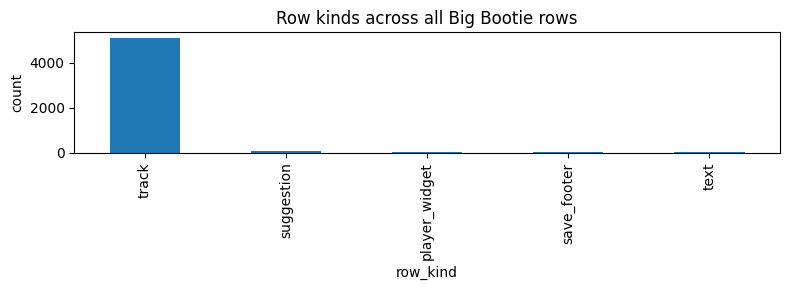

In [7]:
import matplotlib.pyplot as plt

kind_counts = tokens.row_kind.value_counts()
print(kind_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
kind_counts.plot(kind='bar', ax=ax)
ax.set_title('Row kinds across all Big Bootie rows')
ax.set_ylabel('count')
plt.tight_layout(); plt.show()


### Track-row feature prevalence

These booleans are what the downstream alignment pipeline will branch on:

- `is_ided` — community-identified (a reference recording can be fetched)
- `is_concurrent` — layered onto the previous track's cue via the "w/" operator
- `is_remixish` — a remix/rework/acappella/alt-version variant; audio differs from the canonical release
- `has_yt/sc/sp/ap` — which streaming platforms link to this track


is_ided          98.6
is_concurrent    73.1
is_remixish      54.4
has_yt           99.8
has_sc           99.8
has_sp           99.3
has_ap           99.3


/var/folders/b3/vg6l_zw95fddlqg59z441xk80000gn/T/ipykernel_63900/785867733.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pct = (tracks[flag_cols].fillna(False).astype(bool).mean() * 100).round(1)


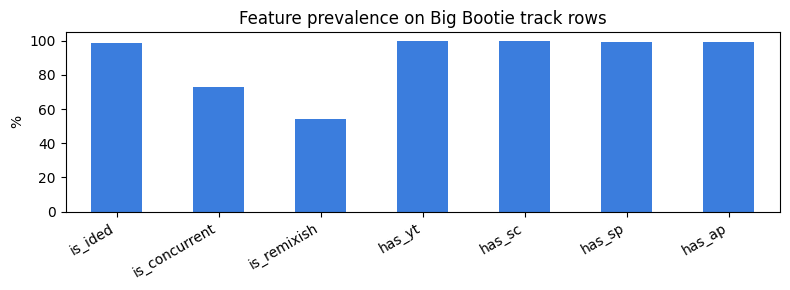

In [8]:
tracks = tokens[tokens.row_kind == 'track'].copy()
flag_cols = ['is_ided','is_concurrent','is_remixish','has_yt','has_sc','has_sp','has_ap']
pct = (tracks[flag_cols].fillna(False).astype(bool).mean() * 100).round(1)
print(pct.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
pct.plot(kind='bar', ax=ax, color='#3b7ddd')
ax.set_title('Feature prevalence on Big Bootie track rows')
ax.set_ylabel('%'); ax.set_ylim(0, 105)
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()


### Cue-point structure — the mashup signature

Every track row carries a `cue_seconds` timestamp pointing at the moment it
enters the mix. But the tracklist HTML only populates the cue on the **parent**
of each layered group; `w/` sub-rows leave it at 0 or None. `big_bootie.py`
forward-fills the last parent cue per set into a resolved `cue_seconds_section`
column — that's what we use below.

So **distinct `cue_seconds_section` per set ≈ audio sections**, and
**track_rows / distinct_cues ≈ average layer depth**.

(Caveat: ~9 of the 30 Big Bootie sets have no cue timestamps scraped at all —
probably older volumes where the HTML structure was different. They'll get
flagged in the next cell.)

In [9]:
per_set_cues   = tracks.dropna(subset=['cue_seconds_section']).groupby('set_id')['cue_seconds_section'].nunique().rename('distinct_cues')
per_set_tracks = tracks.groupby('set_id').size().rename('track_rows')

df_set = (
    per_set_tracks.to_frame()
                  .join(per_set_cues, how='left')   # preserve ALL sets, even those with no cue data
                  .join(bb_sets.set_index('set_id')[['volume','date_played','play_time']])
)
df_set['layer_ratio'] = df_set['track_rows'] / df_set['distinct_cues']
df_set = df_set.sort_values('volume')

bad = df_set[df_set['distinct_cues'].isna()]
if len(bad):
    print(f'WARNING: {len(bad)} of {len(df_set)} Big Bootie sets have no scraped cue timestamps.')
    print('These rows still tokenize but cannot contribute to section-level alignment:')
    print(bad[['volume','date_played','track_rows']].to_string())
    print()

df_set

These rows still tokenize but cannot contribute to section-level alignment:
          volume date_played  track_rows
set_id                                  
4fjz021      4.0  2013-08-15          64
hy83dh1      5.0  2014-02-18          72
w1mgcjt     10.0  2016-10-06         145
2svckg31    22.0  2022-10-15         257
2vpur281    23.0  2023-06-02         250
1mpqt5wk    24.0  2024-02-15         224
1jwtbspt    24.0  2024-02-10         238
l6xqnhk     25.0  2024-08-24         220
1yyp04rt     NaN  2025-05-31         219
k9tu0r1      NaN  2025-05-31          75



,track_rows,distinct_cues,volume,date_played,play_time,layer_ratio
set_id,,,,,,
1kh4dbd1,51,48.0,1.0,2012-05-31,1h 12m,1.062500
qgvujwt,65,59.0,2.0,2012-11-03,1h 7m,1.101695
2ckm8bjk,56,53.0,3.0,2013-03-19,1h 7m,1.056604
4fjz021,64,NaN,4.0,2013-08-15,1h 1m,NaN
hy83dh1,72,NaN,5.0,2014-02-18,1h 3m,NaN
3b0k6zk,69,18.0,6.0,2014-08-18,1h,3.833333
66wusst,101,89.0,7.0,2015-04-07,56m,1.134831
8ktvhkt,124,30.0,8.0,2015-09-28,59m,4.133333
1n81jy3k,130,129.0,9.0,2016-04-20,1h,1.007752


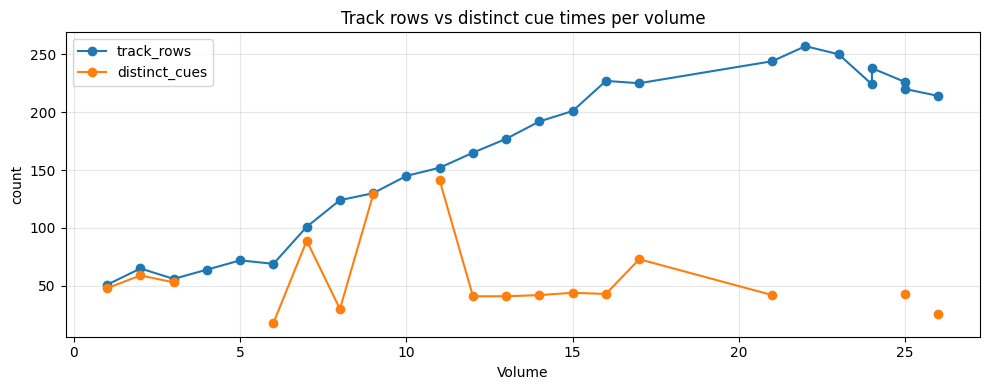

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
df_set.sort_values('volume').plot(x='volume', y=['track_rows','distinct_cues'], marker='o', ax=ax)
ax.set_title('Track rows vs distinct cue times per volume')
ax.set_xlabel('Volume'); ax.set_ylabel('count')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Layer ratios sit well above 1 across the series — most cue sections
host several tracks, confirming these are mashup-dense mixes rather than
conventional DJ sets. Earlier volumes (pre-Vol. 10) tend to run lighter.


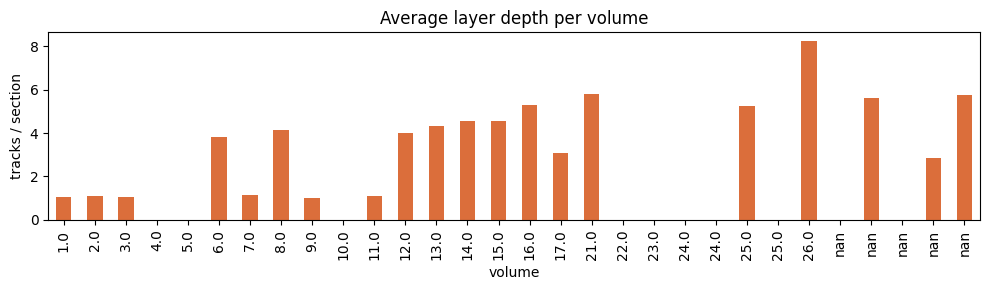

layer ratio  min=1.01  mean=3.69  max=8.23


In [11]:
fig, ax = plt.subplots(figsize=(10, 3))
df_set.sort_values('volume').set_index('volume')['layer_ratio'].plot(kind='bar', ax=ax, color='#db6e3b')
ax.set_title('Average layer depth per volume')
ax.set_ylabel('tracks / section')
plt.tight_layout(); plt.show()

print(f'layer ratio  min={df_set.layer_ratio.min():.2f}  mean={df_set.layer_ratio.mean():.2f}  max={df_set.layer_ratio.max():.2f}')


### Per-section concurrent-group sizes

Zoom into every cue section across the corpus and count the tracks sharing
it. The long tail on the right represents the dense layered moments —
these are the cue sections where the cutup-plan alignment will be hardest.


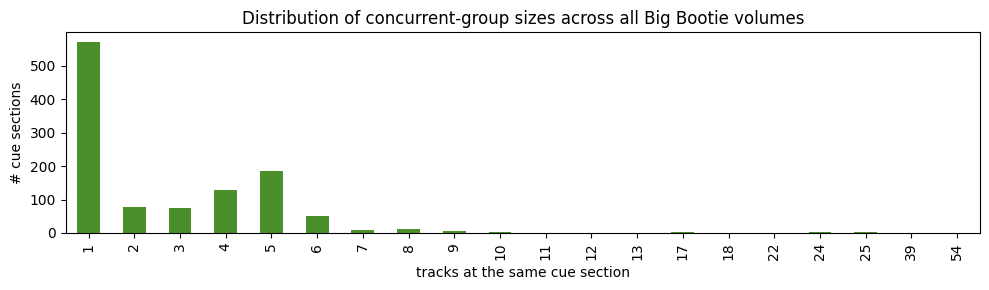

max layer: 54  median layer: 1  mean layer: 2.89


In [12]:
group_sizes = tracks.dropna(subset=['cue_seconds_section']).groupby(['set_id','cue_seconds_section']).size()
dist = group_sizes.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 3))
dist.plot(kind='bar', ax=ax, color='#4a8f2a')
ax.set_title('Distribution of concurrent-group sizes across all Big Bootie volumes')
ax.set_xlabel('tracks at the same cue section'); ax.set_ylabel('# cue sections')
plt.tight_layout(); plt.show()

print(f'max layer: {int(dist.index.max())}  median layer: {int(group_sizes.median())}  mean layer: {group_sizes.mean():.2f}')

### Downloadable-media coverage per volume

Join the tokenized track rows with `dj_set_track_media_links` to see how
many tokens we'll actually be able to fetch audio for. Anything without a
YouTube or SoundCloud link goes to the spotdl fallback or is skipped.


In [13]:
# Map canonical track_id -> set of platforms available
tml_per_track = (
    bb_tml.dropna(subset=['track_id'])
          .groupby('track_id')['platform']
          .apply(lambda p: set(p))
)
tracks['platforms'] = tracks['track_key'].map(tml_per_track)
tracks['downloadable_ytsc'] = tracks['platforms'].apply(
    lambda p: isinstance(p, set) and bool(p & {'youtube','soundcloud'})
)
tracks['spotify_only'] = tracks['platforms'].apply(
    lambda p: isinstance(p, set) and (p <= {'spotify','apple'}) and ('spotify' in p)
)

coverage = (
    tracks.join(bb_sets.set_index('set_id')[['volume']], on='set_id')
          .groupby('volume')
          .agg(
              tracks=('row_index','size'),
              downloadable_ytsc=('downloadable_ytsc','sum'),
              spotify_only=('spotify_only','sum'),
          )
)
coverage['pct_downloadable'] = 100 * coverage['downloadable_ytsc'] / coverage['tracks']
coverage = coverage.sort_index()
coverage


,tracks,downloadable_ytsc,spotify_only,pct_downloadable
volume,,,,
1.0,51,38,5,74.509804
2.0,65,44,5,67.692308
3.0,56,40,4,71.428571
4.0,64,48,10,75.000000
5.0,72,55,2,76.388889
6.0,69,49,9,71.014493
7.0,101,87,1,86.138614
8.0,124,111,5,89.516129
9.0,130,118,6,90.769231


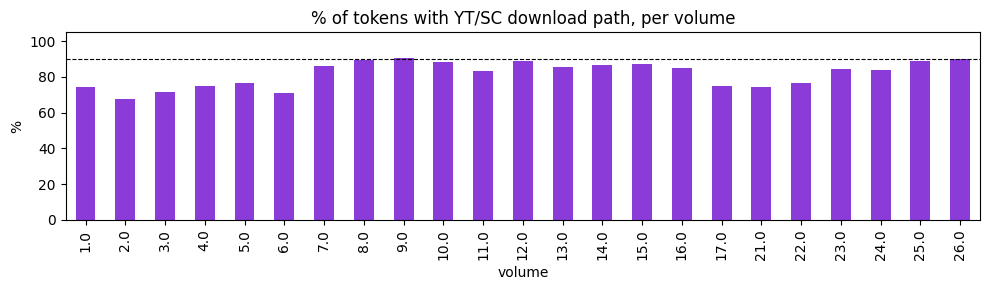

In [14]:
fig, ax = plt.subplots(figsize=(10, 3))
coverage['pct_downloadable'].plot(kind='bar', ax=ax, color='#8a3bd8')
ax.set_title('% of tokens with YT/SC download path, per volume')
ax.set_ylabel('%'); ax.set_ylim(0, 105)
ax.axhline(90, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout(); plt.show()


### Cue-point recovery — can we rescue the 10 cueless sets?

Ten of the 30 Big Bootie sets came back with no usable cue timestamps from the
`dj_set_rows` table. Before resigning ourselves to losing their section
anchors, the crawler actually stored the **full HTML** of every fetched page
on disk at `data/html/<set_id>_<timestamp>.html`. The JS cue table
(`cueValueData.push(cueValuesEntry)`) is embedded directly in that HTML, so
if the source ever had cue times we can extract them with
`big_bootie.extract_cue_points_from_html`.

This cell runs that recovery across all 10 cueless sets. If every set still
comes back with only a single t=0 cue entry, the conclusion is that the
upstream page itself lacks timing data — in which case we have to fall back
to cue-detr on the rendered audio for those volumes.

In [15]:
import glob
from big_bootie import extract_cue_points_from_html

cueless_set_ids = sorted(bad.index.tolist()) if len(bad) else []
print(f'probing {len(cueless_set_ids)} sets that had no cue_seconds in the DB\n')

recovery_rows = []
for sid in cueless_set_ids:
    matches = sorted(HTML_DIR.glob(f'{sid}_*.html'))
    if not matches:
        recovery_rows.append({'set_id': sid, 'html_found': False, 'n_cues': None, 'max_t': None})
        continue
    html = matches[-1].read_text(encoding='utf-8', errors='ignore')
    cues = extract_cue_points_from_html(html)
    max_t = max((c['time_seconds'] for c in cues), default=0)
    recovery_rows.append({'set_id': sid, 'html_found': True, 'n_cues': len(cues), 'max_t': max_t})

recovery = pd.DataFrame(recovery_rows).merge(
    bb_sets[['set_id', 'volume', 'date_played']], on='set_id', how='left',
).sort_values(['volume', 'date_played'], na_position='last')
recovery

probing 10 sets that had no cue_seconds in the DB



,set_id,html_found,n_cues,max_t,volume,date_played
5,4fjz021,True,1,0,4.0,2013-08-15
6,hy83dh1,True,1,0,5.0,2014-02-18
9,w1mgcjt,True,1,0,10.0,2016-10-06
3,2svckg31,True,1,0,22.0,2022-10-15
4,2vpur281,True,1,0,23.0,2023-06-02
0,1jwtbspt,True,1,0,24.0,2024-02-10
1,1mpqt5wk,True,1,0,24.0,2024-02-15
8,l6xqnhk,True,1,0,25.0,2024-08-24
2,1yyp04rt,True,1,0,NaN,2025-05-31
7,k9tu0r1,True,1,0,NaN,2025-05-31


If every row above shows `n_cues=1, max_t=0` then the HTML's JS cue table
contains only a sentinel entry covering all tracks at time zero — a known
1001tracklists pattern for sets where the contributor didn't enter cue
timestamps. In that case the only way to get section anchors for those
volumes is to run **cue-detr** over the rendered audio once we've downloaded
it via `audio_pipeline.main --set-id <id>`.

### Takeaways

- ~**3,265** distinct canonical tracks across all 30 volumes, with **~90% YT/SC-downloadable**.
- Mixes are genuinely **mashup-heavy** — where cue data is intact the layer ratio averages **~3.7 tracks per audio section**, peaking at ~8 on Vol. 26 (the densest).
- ~**9 of 30 sets have no scraped cue timestamps** (older volumes with a different HTML structure). We can still tokenize their rows and use `is_concurrent` + text ordering, but the audio-section anchor has to come from re-scraping or from cue-detr on the rendered audio rather than the HTML.
- The `is_concurrent` flag on a token row is the primary hook for the cutup-plan code: when True, the played audio shares a cue section with the row above, but the stem mask / measure window may differ.
- Pre-Vol. 10 volumes run lighter; later volumes push the mashup density and will stress the alignment pipeline hardest.

Next:
1. Run `python -m audio_pipeline.main --set-id 1d9zwh49` to pull Vol. 26 audio.
2. Re-scrape the 9 cue-less sets (flagged above) if we want cleaner data-quality parity across the whole series.
3. Wire up Demucs + cue-detr + essentia on the downloaded audio.